# Test DataFrame Loading & Heatmap Visualization

Load pre-saved iEEG metrics dataframes and plot correlation heatmap.

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Metrics of interest (9 MOIs) in raw/source names
METRICS_9_ORDER = [
    'salience',
    'dynamic_functional_connectivity_matrix_var_mat',
    'max_dynamic_network_profile',
    'Entropy_FC',
    'phase_coherence_matrix_mean_mat',
    'N1',
    'N2',
]

# Display labels requested by user (same order as raw list above)
METRICS_9_LABELS = [
    'Salience',
    'Fluidity',
    'Peak Synchrony',
    'Complexity',
    'Entrainment',
    'N1_amplitude',
    'N2_amplitude',
]

# Mapping: raw/source metric name -> display label
METRIC_LABEL_MAP = dict(zip(METRICS_9_ORDER, METRICS_9_LABELS))

# Ordered labels requested for output sorting
ordered_metrics = [
    'Salience',
    'Peak Synchrony',
    'Entrainment',
    'Fluidity',
    'Complexity',
    'N1_amplitude',
    'N2_amplitude',
]

In [10]:
# Resolve project root
cwd = Path.cwd().resolve()
if (cwd / 'data').exists():
    project_root = cwd
elif (cwd.parent / 'data').exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError('Could not find project root containing data/.')

metrics_root = project_root / 'data' / 'df_results' / 'ieeg_metrics'
print(f'Project root: {project_root}')
print(f'Metrics root: {metrics_root}')

Project root: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main
Metrics root: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/ieeg_metrics


In [11]:
# Load df_9MOIs
csv_path_9mois = metrics_root / 'df_9MOIs_ieeg.csv'
df_9MOIs = pd.read_csv(csv_path_9mois)

# Convert metric_name to ordered categorical
df_9MOIs['metric_name'] = pd.Categorical(
    df_9MOIs['metric_name'],
    categories=METRICS_9_ORDER,
    ordered=True,
)

print(f'Loaded df_9MOIs from {csv_path_9mois}')
print(f'Shape: {df_9MOIs.shape}')
df_9MOIs.head()

Loaded df_9MOIs from /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/ieeg_metrics/df_9MOIs_ieeg.csv
Shape: (3246210, 8)


,sub,radius_pre,radius_post,run_is,trial_id,metric_name,metric_value_pre,metric_value_post
0,sub-01,5,5,run-01,0,salience,1.023810,1.185404
1,sub-01,5,5,run-01,0,dynamic_functional_connectivity_matrix_var_mat,0.024316,0.013314
2,sub-01,5,5,run-01,0,max_dynamic_network_profile,7.193256,10.081182
3,sub-01,5,5,run-01,0,Entropy_FC,1.226086,1.093238
4,sub-01,5,5,run-01,0,phase_coherence_matrix_mean_mat,0.527392,0.478199


In [12]:
# Load df_9MOIs_corr
csv_path_corr = metrics_root / 'df_correlations_9MOIs_ieeg.csv'
df_9MOIs_corr = pd.read_csv(csv_path_corr)

# Convert metric columns to ordered categoricals
df_9MOIs_corr['Pre_Metric'] = pd.Categorical(
    df_9MOIs_corr['Pre_Metric'],
    categories=METRICS_9_ORDER,
    ordered=True,
)
df_9MOIs_corr['Post_Metric'] = pd.Categorical(
    df_9MOIs_corr['Post_Metric'],
    categories=METRICS_9_ORDER,
    ordered=True,
)

print(f'Loaded df_9MOIs_corr from {csv_path_corr}')
print(f'Shape: {df_9MOIs_corr.shape}')
df_9MOIs_corr.head()

Loaded df_9MOIs_corr from /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/ieeg_metrics/df_correlations_9MOIs_ieeg.csv
Shape: (850014, 10)


,Patient,Session,Radius_pre,Radius_post,Pre_Metric,Post_Metric,Correlation,Significance,p-values,Network
0,P1,S1,5,5,salience,salience,0.568668,1,0.000129,NaN
1,P1,S1,5,5,salience,dynamic_functional_connectivity_matrix_var_mat,-0.205816,0,0.202624,NaN
2,P1,S1,5,5,salience,max_dynamic_network_profile,0.464353,1,0.002541,NaN
3,P1,S1,5,5,salience,Entropy_FC,-0.091932,0,0.572624,NaN
4,P1,S1,5,5,salience,phase_coherence_matrix_mean_mat,0.057974,0,0.722342,NaN


/var/folders/9d/t9bsbbcj6tb1lzb02lt5xkfc0000gq/T/ipykernel_1840/4024830072.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df


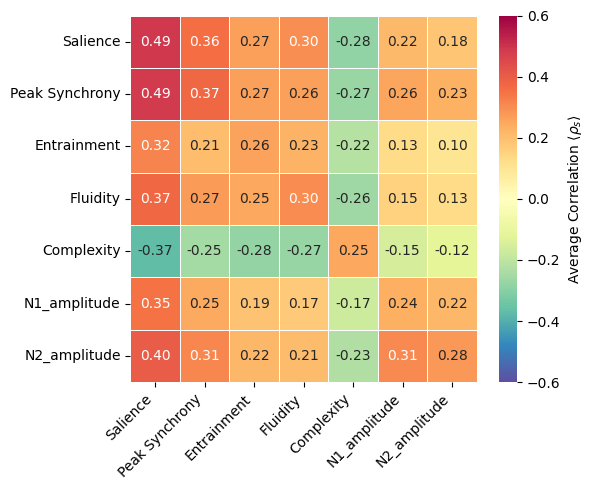

In [14]:
# Plot Spearman correlation heatmap (ordered by ordered_metrics, labeled with display names)
# Use display labels for plotting
plot_order = ordered_metrics  # desired display order

# Filter to requested radius pair only
plot_df = df_9MOIs_corr.loc[
    (df_9MOIs_corr['Radius_pre'] == 100) & (df_9MOIs_corr['Radius_post'] == 100)
].copy()

# Map raw metric names to display labels and average correlations over selected groups
plot_df['Pre_Metric_Label'] = plot_df['Pre_Metric'].map(METRIC_LABEL_MAP)
plot_df['Post_Metric_Label'] = plot_df['Post_Metric'].map(METRIC_LABEL_MAP)

corr_matrix = (
    plot_df
    .groupby(['Pre_Metric_Label', 'Post_Metric_Label'], dropna=False)['Correlation']
    .mean()
    .unstack('Post_Metric_Label')
    .reindex(index=plot_order, columns=plot_order)
)

# Ensure square figure shape
plt.figure(figsize=(6, 5))

# Plot the heatmap
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='Spectral_r',
    fmt='.2f',
    linewidths=0.5,
    vmin=-0.6,
    vmax=0.6,
    cbar_kws={'label': r'Average Correlation $\langle \rho_s \rangle$'}
)

# Set axis labels
plt.ylabel('')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()